# CTDS Initialization Testing

Tests the four-stage initialization pipeline implemented in `models.py`:

```
Y  →  estimate_J  →  blockwise_NMF  →  initialize_emissions  →  initialize_dynamics
```

Each stage is tested in isolation before the full pipeline is tested end-to-end.

| Test | Stage | Primary question |
|------|-------|------------------|
| 1 | `estimate_J` | Does the constrained QP recover a valid Dale-law J? |
| 2 | `blockwise_NMF` | Does NMF reconstruct `\|J\| ≈ U V_dale^T`? |
| 3 | `initialize_emissions` | Is C block-diagonal, nonneg, and in the right subspace? |
| 4 | `initialize_dynamics` | Does A satisfy Dale signs and is it stable? |
| 5 | End-to-end EM | Does NNMF init beat random init in convergence speed? |
| 6 | Data sensitivity | How does init quality degrade with shorter T? |
| 7 | Constraint audit | Are Dale constraints preserved at every pipeline stage? |

## 0. Setup

In [7]:
import sys, os

#REPO_ROOT = os.path.abspath("..")   # adjust if notebook is not one level below repo root
#if REPO_ROOT not in sys.path:
   # sys.path.insert(0, REPO_ROOT)

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.linalg import subspace_angles

from params import (
    ParamsCTDS, ParamsCTDSConstraints,
    ParamsCTDSInitial, ParamsCTDSDynamics, ParamsCTDSEmissions
)
from models import CTDS
from utlis import estimate_J, blockwise_NMF
from simulation_utilis import generate_synthetic_data

sns.set_theme(style="whitegrid", font_scale=1.15)
SEED = 42
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


In [8]:
# ── Experiment constants ─────────────────────────────────────────────────────
N_E, N_I = 14, 6          # neurons per cell type
N = N_E + N_I             # total neurons
D_E, D_I = 2, 2           # latent dims per cell type
D = D_E + D_I             # total latent dims
T = 500                   # default number of time steps
B = 5                     # number of trials

# ── Cell-type bookkeeping ─────────────────────────────────────────────────────
cell_types          = jnp.array([0, 1])          # 0=E, 1=I
cell_sign           = jnp.array([1, -1])         # E=+1, I=-1
cell_type_dimensions= jnp.array([D_E, D_I])
cell_type_mask      = jnp.array([0]*N_E + [1]*N_I)   # (N,) neuron→type
dynamics_mask       = jnp.repeat(cell_sign, cell_type_dimensions)  # (D,)

constraints = ParamsCTDSConstraints(
    cell_types=cell_types,
    cell_sign=cell_sign,
    cell_type_dimensions=cell_type_dimensions,
    cell_type_mask=cell_type_mask,
)

e_mask = cell_type_mask == 0   # (N,) bool: True for E neurons
dale_mask = e_mask             # alias used by estimate_J

print(f"N={N} (E={N_E}, I={N_I})  D={D} (D_E={D_E}, D_I={D_I})  T={T}  B={B}")
print(f"dynamics_mask: {dynamics_mask}")

N=20 (E=14, I=6)  D=4 (D_E=2, D_I=2)  T=500  B=5
dynamics_mask: [ 1  1 -1 -1]


In [9]:
# ── Generate a single ground-truth dataset ───────────────────────────────────
key = jr.PRNGKey(SEED)
latents_BT, obs_BTN,ctds, true_params = generate_synthetic_data(
        num_samples=B,
        num_timesteps=T,
        state_dim=D,
        emission_dim=N,
        cell_types=2,
        key=key,
)
 
# obs_BTN shape: (B, T, N) or (T, N) — normalise to (B, T, N)
if obs_BTN.ndim == 2:
    obs_BTN = obs_BTN[None]   # (1, T, N)
print("obs_BTN shape:", obs_BTN.shape)

C_true = true_params.emissions.weights   # (N, D)
A_true = true_params.dynamics.weights    # (D, D)
Q_true = true_params.dynamics.cov        # (D, D)
R_true = true_params.emissions.cov       # (N, N) or (N,)

# J_true = C_true @ A_true @ pinv(C_true)  projected to observation space
# For initialization we compare against the low-rank J defined in the paper:
#   J = C @ A @ pinv(C)  restricted to the neuron subspace.
# The simplest useful reference is the one-step regression target:
#   J_lin * Y_past ≈ Y_future.  We call this J_reg_true = A_true directly.
print("C_true:", C_true.shape, "  A_true:", A_true.shape)

obs_BTN shape: (5, 500, 20)
C_true: (20, 4)   A_true: (4, 4)


In [10]:
# ── Helper: flatten observations to (N, T_total) centered ───────────────────
def flatten_and_center(obs_BTN):
    """Return Y_center (N, T_total) and bias (N,)."""
    B_, T_, N_ = obs_BTN.shape
    Y = obs_BTN.reshape(B_ * T_, N_).T   # (N, T_total)
    bias = jnp.mean(Y, axis=1)
    Y_center = Y - bias[:, None]
    return Y_center, bias

Y_center, bias = flatten_and_center(obs_BTN)
print("Y_center shape:", Y_center.shape)

Y_center shape: (20, 2500)


---
## Test 1 — `estimate_J`: Dale-law regression quality

Checks:
- **Sign structure**: E-columns of `J_hat` are nonneg, I-columns are nonpos
- **Regression fit**: `‖Y_{t+1} − J_hat Y_t‖_F / ‖Y_{t+1}‖_F`
- **Recovery vs T**: does `‖J_hat − J_true‖_F` shrink with more data?

In [11]:
# ── Run estimate_J on default dataset ────────────────────────────────────────
J_hat = estimate_J(Y_center, dale_mask)
print("J_hat shape:", J_hat.shape)

# ── Sign-structure check ──────────────────────────────────────────────────────
tol = 1e-3
E_cols = J_hat[:, :N_E]   # columns for E neurons (source is E)
I_cols = J_hat[:, N_E:]   # columns for I neurons (source is I)

# Note: estimate_J operates on J where J[i,j] = weight FROM neuron j TO neuron i
# Dale's law: E neurons (j<N_E) have nonneg outgoing weights → J[:,j] >= 0
#             I neurons (j>=N_E) have nonpos outgoing weights → J[:,j] <= 0
E_violations = jnp.sum(E_cols < -tol)
I_violations = jnp.sum(I_cols > tol)
print(f"Dale sign violations — E cols: {int(E_violations)},  I cols: {int(I_violations)}")

# ── Regression fit ────────────────────────────────────────────────────────────
Y_past   = Y_center[:, :-1]   # (N, T-1)
Y_future = Y_center[:, 1:]    # (N, T-1)
residual = Y_future - J_hat @ Y_past
fit_err  = jnp.linalg.norm(residual, 'fro') / jnp.linalg.norm(Y_future, 'fro')
print(f"Relative regression residual: {float(fit_err):.4f}")

J_hat shape: (20, 20)
Dale sign violations — E cols: 0,  I cols: 0
Relative regression residual: 0.9814


In [12]:
# ── Sweep over T: does J recovery improve? ────────────────────────────────────
T_vals = [100, 200, 500, 1000]
sign_viol, fit_errs = [], []

for T_test in T_vals:
    key_t = jr.PRNGKey(SEED + T_test)
    _, obs_t,_, _ =generate_synthetic_data(
        num_samples=B,
        num_timesteps=T_test,
        state_dim=D,
        emission_dim=N,
        cell_types=2,
        key=key_t)
    if obs_t.ndim == 2: obs_t = obs_t[None]
    Yc_t, _ = flatten_and_center(obs_t)
    Jh = estimate_J(Yc_t, dale_mask)

    Yp, Yf = Yc_t[:, :-1], Yc_t[:, 1:]
    fe = float(jnp.linalg.norm(Yf - Jh @ Yp, 'fro') / jnp.linalg.norm(Yf, 'fro'))
    sv = int(jnp.sum(Jh[:, :N_E] < -tol) + jnp.sum(Jh[:, N_E:] > tol))
    sign_viol.append(sv)
    fit_errs.append(fe)
    print(f"  T={T_test:5d}  sign_violations={sv:3d}  fit_err={fe:.4f}")


  T=  100  sign_violations=  0  fit_err=0.9642
  T=  200  sign_violations=  0  fit_err=0.9717
  T=  500  sign_violations=  0  fit_err=0.9794
  T= 1000  sign_violations=  0  fit_err=0.9829


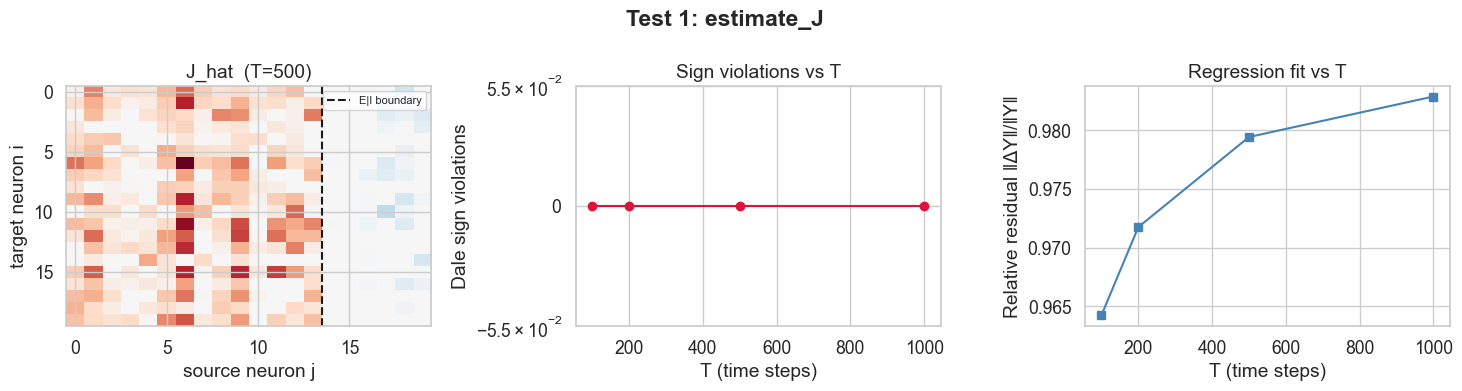

Dale violations at T=500: E=0, I=0
Relative regression residual at T=500: 0.9814


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Test 1: estimate_J", fontweight='bold')

# Heatmap J_hat
vmax = float(jnp.abs(J_hat).max())
axes[0].imshow(np.array(J_hat), cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
axes[0].set_title(f"J_hat  (T={T})")
axes[0].axvline(N_E - 0.5, color='k', lw=1.5, ls='--', label='E|I boundary')
axes[0].set_xlabel("source neuron j")
axes[0].set_ylabel("target neuron i")
axes[0].legend(fontsize=8)

# Sign violations vs T
axes[1].plot(T_vals, sign_viol, 'o-', color='crimson')
axes[1].set_xlabel("T (time steps)")
axes[1].set_ylabel("Dale sign violations")
axes[1].set_title("Sign violations vs T")
axes[1].set_yscale('symlog')   # 0 is fine

# Regression fit vs T
axes[2].plot(T_vals, fit_errs, 's-', color='steelblue')
axes[2].set_xlabel("T (time steps)")
axes[2].set_ylabel("Relative residual ‖ΔY‖/‖Y‖")
axes[2].set_title("Regression fit vs T")

plt.tight_layout()
plt.savefig("init_test1_estimateJ.pdf", bbox_inches='tight')
plt.show()
print(f"Dale violations at T={T}: E={int(E_violations)}, I={int(I_violations)}")
print(f"Relative regression residual at T={T}: {float(fit_err):.4f}")

---
## Test 2 — `blockwise_NMF`: reconstruction of `|J|`

Checks:
- **Reconstruction**: `‖|J| − U V^T‖_F / ‖|J|‖_F` is small
- **Nonnegativity**: `min(U) >= 0`, `min(V) >= 0`
- **Sign-corrected reconstruction**: `‖J − U V_dale^T‖_F` where V_dale negates I-rows

In [14]:
# ── Run blockwise_NMF on J_hat ────────────────────────────────────────────────
block_factors = blockwise_NMF(J_hat, constraints)
# block_factors: list of (U_type, V_type) per cell type
# U_type: (N_type, D_type)   V_type: (N, D_type)

U_list = [tup[0] for tup in block_factors]
V_list = [tup[1] for tup in block_factors]

# Assemble full U (block-diagonal, padded) and V
# U has shape (N, D) with blocks in correct column positions
U_blocks = []
col_start = 0
for i, (U_type, V_type) in enumerate(block_factors):
    N_type, D_type = U_type.shape
    left  = jnp.zeros((N_type, col_start))
    right = jnp.zeros((N_type, D - col_start - D_type))
    U_blocks.append(jnp.concatenate([left, U_type, right], axis=1))
    col_start += D_type
U_full = jnp.concatenate(U_blocks, axis=0)   # (N, D)

# V_dale: stack V columns, negate I-type rows
V_stacked = jnp.concatenate(V_list, axis=1)  # (N, D)
V_dale = V_stacked * cell_sign[cell_type_mask][:, None]  # sign flip per neuron type

# Reconstruction errors
J_plus = jnp.abs(J_hat)
recon_abs = U_full @ V_stacked.T   # (N, N)  reconstructs |J|
recon_signed = U_full @ V_dale.T   # (N, N)  reconstructs J with signs

err_abs    = float(jnp.linalg.norm(J_plus - recon_abs, 'fro') / jnp.linalg.norm(J_plus, 'fro'))
err_signed = float(jnp.linalg.norm(J_hat - recon_signed, 'fro') / jnp.linalg.norm(J_hat, 'fro'))

print(f"‖|J| − U V^T‖_F / ‖|J|‖_F       = {err_abs:.4f}")
print(f"‖J  − U V_dale^T‖_F / ‖J‖_F      = {err_signed:.4f}")
print(f"min(U_full) = {float(jnp.min(U_full)):.4f}  (should be >= 0)")
print(f"min(V_stacked) = {float(jnp.min(V_stacked)):.4f}  (should be >= 0)")

‖|J| − U V^T‖_F / ‖|J|‖_F       = 0.3391
‖J  − U V_dale^T‖_F / ‖J‖_F      = 0.3391
min(U_full) = 0.0000  (should be >= 0)
min(V_stacked) = 0.0000  (should be >= 0)


In [15]:
# ── Sweep over D_fit: reconstruction error vs rank used ───────────────────────
D_fit_vals = [1, 2, 3, 4, 6, 8]
recon_errs_abs, recon_errs_signed = [], []

for D_fit_total in D_fit_vals:
    # Split evenly: D_E_fit = D_I_fit = D_fit_total // 2  (or adjust)
    D_E_fit = max(1, D_fit_total // 2)
    D_I_fit = max(1, D_fit_total - D_E_fit)
    constraints_fit = ParamsCTDSConstraints(
        cell_types=cell_types,
        cell_sign=cell_sign,
        cell_type_dimensions=jnp.array([D_E_fit, D_I_fit]),
        cell_type_mask=cell_type_mask,
    )
    bf = blockwise_NMF(J_hat, constraints_fit)
    U_l = [t[0] for t in bf]
    V_l = [t[1] for t in bf]
    D_tot = D_E_fit + D_I_fit

    Ub = []
    cs = 0
    for i2, (Ut, Vt) in enumerate(bf):
        Nt2, Dt2 = Ut.shape
        Ub.append(jnp.concatenate([jnp.zeros((Nt2, cs)), Ut, jnp.zeros((Nt2, D_tot - cs - Dt2))], axis=1))
        cs += Dt2
    Uf = jnp.concatenate(Ub, axis=0)
    Vs = jnp.concatenate(V_l, axis=1)
    Vd = Vs * cell_sign[cell_type_mask][:, None]

    ea = float(jnp.linalg.norm(J_plus - Uf @ Vs.T, 'fro') / jnp.linalg.norm(J_plus, 'fro'))
    es = float(jnp.linalg.norm(J_hat  - Uf @ Vd.T, 'fro') / jnp.linalg.norm(J_hat,  'fro'))
    recon_errs_abs.append(ea)
    recon_errs_signed.append(es)
    print(f"  D_fit={D_fit_total}  err_abs={ea:.4f}  err_signed={es:.4f}")

  D_fit=1  err_abs=0.4195  err_signed=0.4195
  D_fit=2  err_abs=0.4195  err_signed=0.4195
  D_fit=3  err_abs=0.3933  err_signed=0.3933
  D_fit=4  err_abs=0.3391  err_signed=0.3391
  D_fit=6  err_abs=0.2857  err_signed=0.2857
  D_fit=8  err_abs=0.2398  err_signed=0.2398


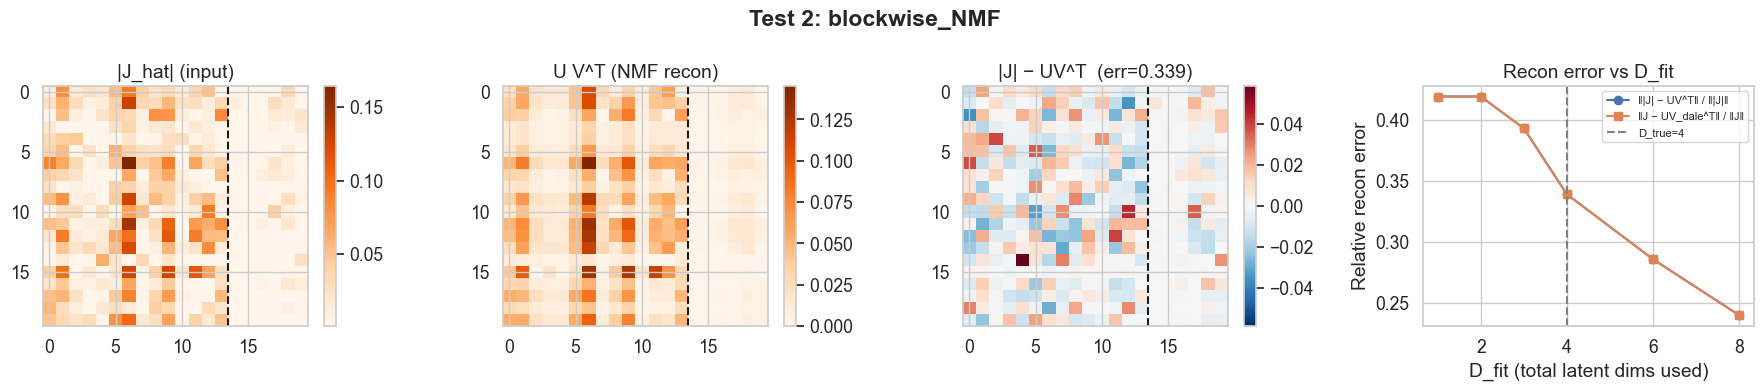

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Test 2: blockwise_NMF", fontweight='bold')

vmax2 = float(jnp.abs(J_hat).max())

im0 = axes[0].imshow(np.array(jnp.abs(J_hat)), cmap='Oranges', aspect='auto')
axes[0].set_title("|J_hat| (input)");  fig.colorbar(im0, ax=axes[0])
axes[0].axvline(N_E - 0.5, color='k', lw=1.5, ls='--')

im1 = axes[1].imshow(np.array(recon_abs), cmap='Oranges', aspect='auto')
axes[1].set_title("U V^T (NMF recon)");  fig.colorbar(im1, ax=axes[1])
axes[1].axvline(N_E - 0.5, color='k', lw=1.5, ls='--')

residual_mat = np.array(jnp.abs(J_hat) - recon_abs)
vrmax = np.abs(residual_mat).max()
im2 = axes[2].imshow(residual_mat, cmap='RdBu_r', vmin=-vrmax, vmax=vrmax, aspect='auto')
axes[2].set_title(f"|J| − UV^T  (err={err_abs:.3f})");  fig.colorbar(im2, ax=axes[2])
axes[2].axvline(N_E - 0.5, color='k', lw=1.5, ls='--')

axes[3].plot(D_fit_vals, recon_errs_abs,    'o-', label='‖|J| − UV^T‖ / ‖|J|‖')
axes[3].plot(D_fit_vals, recon_errs_signed, 's-', label='‖J − UV_dale^T‖ / ‖J‖')
axes[3].axvline(D, color='gray', ls='--', label=f'D_true={D}')
axes[3].set_xlabel("D_fit (total latent dims used)");  axes[3].set_ylabel("Relative recon error")
axes[3].set_title("Recon error vs D_fit");  axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig("init_test2_nmf.pdf", bbox_inches='tight')
plt.show()

---
## Test 3 — `initialize_emissions`: C structure

Checks:
- **Block-diagonal structure**: zero-blocks are exactly zero
- **Nonnegativity**: `min(C_init) >= 0`
- **Subspace alignment**: principal angles between `col(C_init)` and `col(C_true)`

In [17]:
# ── Run the full initialize() method on our data ──────────────────────────────
model = CTDS(
    emission_dim=N,
    cell_types=cell_types,
    cell_sign=cell_sign,
    cell_type_dimensions=cell_type_dimensions,
    cell_type_mask=cell_type_mask,
)

# initialize() expects (B, T, N)
init_params = model.initialize(obs_BTN)
C_init = init_params.emissions.weights   # (N, D)
print("C_init shape:", C_init.shape)

# ── Block-diagonal structure check ───────────────────────────────────────────
# Expected zero blocks: E neurons (rows 0:N_E) in I columns (cols D_E:D)
#                       I neurons (rows N_E:N) in E columns (cols 0:D_E)
E_I_block = C_init[:N_E, D_E:]   # should be zero
I_E_block = C_init[N_E:, :D_E]   # should be zero
max_E_I_leak = float(jnp.max(jnp.abs(E_I_block)))
max_I_E_leak = float(jnp.max(jnp.abs(I_E_block)))
print(f"Max leakage E→I-block: {max_E_I_leak:.2e}  (should be 0)")
print(f"Max leakage I→E-block: {max_I_E_leak:.2e}  (should be 0)")

# ── Nonnegativity ─────────────────────────────────────────────────────────────
min_C = float(jnp.min(C_init))
print(f"min(C_init) = {min_C:.4f}  (should be >= 0)")

# ── Subspace alignment via principal angles ────────────────────────────────────
init_ang, _ = jnp.linalg.qr(C_init)       # (N, D)
true_ang, _ = jnp.linalg.qr(C_true)       # (N, D)
angles_rad = subspace_angles(np.array(init_ang), np.array(true_ang))
angles_deg = np.degrees(angles_rad)
print(f"Principal angles between col(C_init) and col(C_true): {np.round(angles_deg, 2)} degrees")
print(f"Mean principal angle: {angles_deg.mean():.2f}°")

Y shape (2500, 20)
C_init shape: (20, 4)
Max leakage E→I-block: 0.00e+00  (should be 0)
Max leakage I→E-block: 0.00e+00  (should be 0)
min(C_init) = 0.0000  (should be >= 0)
Principal angles between col(C_init) and col(C_true): [88.45 66.78 31.69  5.84] degrees
Mean principal angle: 48.19°


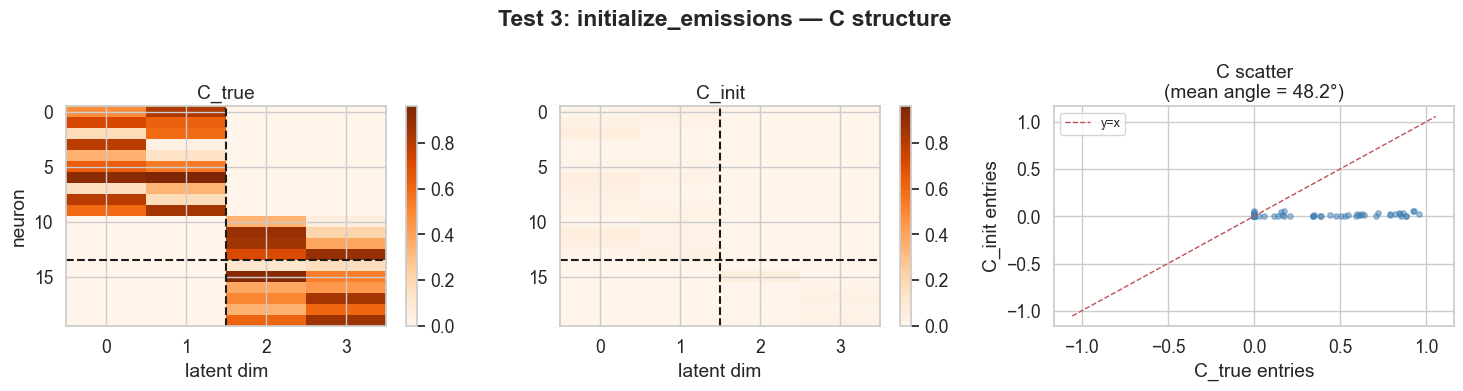

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Test 3: initialize_emissions — C structure", fontweight='bold')

vmax3 = max(float(jnp.abs(C_true).max()), float(jnp.abs(C_init).max()))

im0 = axes[0].imshow(np.array(C_true), cmap='Oranges', aspect='auto', vmin=0, vmax=vmax3)
axes[0].set_title("C_true")
axes[0].set_xlabel("latent dim"); axes[0].set_ylabel("neuron")
axes[0].axhline(N_E - 0.5, color='k', lw=1.5, ls='--')
axes[0].axvline(D_E - 0.5, color='k', lw=1.5, ls='--')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.array(C_init), cmap='Oranges', aspect='auto', vmin=0, vmax=vmax3)
axes[1].set_title("C_init")
axes[1].set_xlabel("latent dim")
axes[1].axhline(N_E - 0.5, color='k', lw=1.5, ls='--')
axes[1].axvline(D_E - 0.5, color='k', lw=1.5, ls='--')
fig.colorbar(im1, ax=axes[1])

# Scatter: C_true vs C_init entries (for matching dims only)
axes[2].scatter(np.array(C_true).ravel(), np.array(C_init).ravel(), alpha=0.5, s=15, color='steelblue')
lim = max(float(jnp.abs(C_true).max()), float(jnp.abs(C_init).max())) * 1.1
axes[2].plot([-lim, lim], [-lim, lim], 'r--', lw=1, label='y=x')
axes[2].set_xlabel("C_true entries"); axes[2].set_ylabel("C_init entries")
axes[2].set_title(f"C scatter\n(mean angle = {angles_deg.mean():.1f}°)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("init_test3_emissions.pdf", bbox_inches='tight')
plt.show()

---
## Test 4 — `initialize_dynamics`: A structure and stability

Checks:
- **Dale signs on A**: E-columns nonneg, I-columns nonpos (off-diagonal)
- **Spectral radius** `< 1` (stable initialization)
- **A_init vs A_random baseline**: is the initialization closer to A_true than random?

In [19]:
A_init = init_params.dynamics.weights   # (D, D)
print("A_init shape:", A_init.shape)

# ── Dale sign check ───────────────────────────────────────────────────────────
# dynamics_mask: +1 for E dims, -1 for I dims
# Dale's law on A: column j has sign dynamics_mask[j] for off-diagonal entries
A_tol = 1e-3
dale_viol = 0
for j in range(D):
    col = A_init[:, j]
    off_diag = jnp.concatenate([col[:j], col[j+1:]])
    if dynamics_mask[j] == 1:   # excitatory col → off-diag should be >= 0
        dale_viol += int(jnp.sum(off_diag < -A_tol))
    else:                       # inhibitory col → off-diag should be <= 0
        dale_viol += int(jnp.sum(off_diag > A_tol))
print(f"A_init Dale violations: {dale_viol}  (should be 0)")

# ── Spectral radius ───────────────────────────────────────────────────────────
eigs_init = jnp.linalg.eigvals(A_init)
eigs_true = jnp.linalg.eigvals(A_true)
sr_init = float(jnp.max(jnp.abs(eigs_init)))
sr_true = float(jnp.max(jnp.abs(eigs_true)))
print(f"Spectral radius — A_init: {sr_init:.4f}   A_true: {sr_true:.4f}")

# ── A_init vs random baseline ─────────────────────────────────────────────────
key_rand = jr.PRNGKey(99)
A_rand = jr.normal(key_rand, (D, D)) * 0.1
err_init = float(jnp.linalg.norm(A_init - A_true, 'fro') / jnp.linalg.norm(A_true, 'fro'))
err_rand = float(jnp.linalg.norm(A_rand - A_true, 'fro') / jnp.linalg.norm(A_true, 'fro'))
print(f"‖A_init − A_true‖_F / ‖A_true‖_F = {err_init:.4f}")
print(f"‖A_rand − A_true‖_F / ‖A_true‖_F = {err_rand:.4f}  (random baseline)")

A_init shape: (4, 4)
A_init Dale violations: 0  (should be 0)
Spectral radius — A_init: 0.5113   A_true: 0.9500
‖A_init − A_true‖_F / ‖A_true‖_F = 0.7030
‖A_rand − A_true‖_F / ‖A_true‖_F = 1.1224  (random baseline)


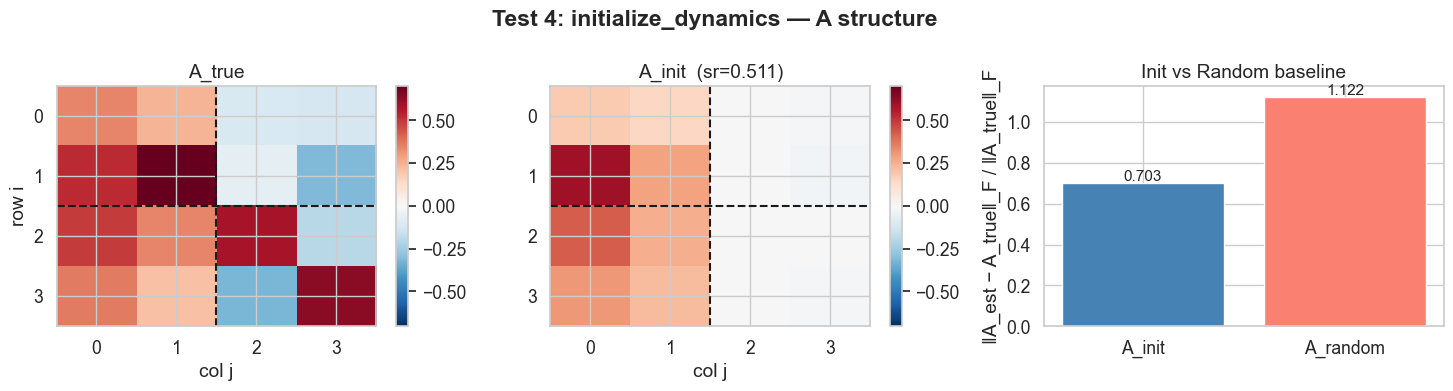

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Test 4: initialize_dynamics — A structure", fontweight='bold')

vmax4 = max(float(jnp.abs(A_true).max()), float(jnp.abs(A_init).max()))
kwargs = dict(cmap='RdBu_r', aspect='auto', vmin=-vmax4, vmax=vmax4)

im0 = axes[0].imshow(np.array(A_true), **kwargs)
axes[0].set_title("A_true");  axes[0].set_xlabel("col j");  axes[0].set_ylabel("row i")
axes[0].axvline(D_E - 0.5, color='k', lw=1.5, ls='--');  axes[0].axhline(D_E - 0.5, color='k', lw=1.5, ls='--')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.array(A_init), **kwargs)
axes[1].set_title(f"A_init  (sr={sr_init:.3f})");  axes[1].set_xlabel("col j")
axes[1].axvline(D_E - 0.5, color='k', lw=1.5, ls='--');  axes[1].axhline(D_E - 0.5, color='k', lw=1.5, ls='--')
fig.colorbar(im1, ax=axes[1])

# Bar chart: relative errors
labels = ['A_init', 'A_random']
errors = [err_init, err_rand]
bars = axes[2].bar(labels, errors, color=['steelblue', 'salmon'])
axes[2].set_ylabel("‖A_est − A_true‖_F / ‖A_true‖_F")
axes[2].set_title("Init vs Random baseline")
for bar, val in zip(bars, errors):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("init_test4_dynamics.pdf", bbox_inches='tight')
plt.show()

---
## Test 5 — End-to-end: NNMF init vs random init vs oracle init

Three EM runs on the same data from three starting points:
1. **NNMF init** — `model.initialize()`
2. **Random init** — random `C`, `A`, `Q`, `R`
3. **Oracle init** — `C_true`, `A_true`, `Q_true`, `R_true`

Key questions: Is LL at iteration 0 higher for NNMF? Does it converge faster?

In [21]:
N_ITERS = 50   # number of EM iterations

# ── Helper: build random init params ─────────────────────────────────────────
def make_random_params(key):
    k1, k2, k3, k4 = jr.split(key, 4)
    C_rand = jnp.abs(jr.normal(k1, (N, D))) * 0.3
    A_rand = jr.normal(k2, (D, D)) * 0.1
    Q_rand = 1e-2 * jnp.eye(D)
    R_rand = jnp.diag(jnp.abs(jr.normal(k3, (N,))) * 0.1 + 1e-3)
    return ParamsCTDS(
        initial=ParamsCTDSInitial(mean=jnp.zeros(D), cov=jnp.eye(D)),
        dynamics=ParamsCTDSDynamics(weights=A_rand, cov=Q_rand, dynamics_mask=dynamics_mask),
        emissions=ParamsCTDSEmissions(weights=C_rand, cov=R_rand, bias=jnp.zeros(N)),
        constraints=constraints,
        observations=obs_BTN,
    )

# ── Helper: build oracle init params ─────────────────────────────────────────
def make_oracle_params():
    R_diag = jnp.diag(R_true) if R_true.ndim == 2 else R_true
    return ParamsCTDS(
        initial=ParamsCTDSInitial(mean=jnp.zeros(D), cov=jnp.eye(D)),
        dynamics=ParamsCTDSDynamics(weights=A_true, cov=Q_true, dynamics_mask=dynamics_mask),
        emissions=ParamsCTDSEmissions(weights=C_true, cov=jnp.diag(R_diag), bias=jnp.zeros(N)),
        constraints=constraints,
        observations=obs_BTN,
    )

params_nnmf   = init_params
params_random = make_random_params(jr.PRNGKey(7))
params_oracle = make_oracle_params()
print("All three init param sets built successfully.")

All three init param sets built successfully.


In [22]:
# ── Run EM from each init ─────────────────────────────────────────────────────
# model.fit_em returns (params_final, log_probs) where log_probs is length N_ITERS
print("Running EM from NNMF init...")
params_nnmf_final,   lls_nnmf   = model.fit_em(params_nnmf,   batch_emissions=obs_BTN, num_iters=N_ITERS)

print("Running EM from random init...")
params_random_final, lls_random = model.fit_em(params_random, batch_emissions=obs_BTN, num_iters=N_ITERS)

print("Running EM from oracle init...")
params_oracle_final, lls_oracle = model.fit_em(params_oracle, batch_emissions=obs_BTN, num_iters=N_ITERS)

print("Done.")
print(f"  Final LL — NNMF: {float(lls_nnmf[-1]):.2f}  Random: {float(lls_random[-1]):.2f}  Oracle: {float(lls_oracle[-1]):.2f}")

Running EM from NNMF init...
Iteration 1: ll=-9.676756258357637  rel_change=1.3555284324866177e-05
Iteration 2: ll=-9.676617372567309  rel_change=1.4352515101106487e-05
Iteration 3: ll=-9.673764480410833  rel_change=0.0002948232886176366
Iteration 4: ll=-9.620913258978874  rel_change=0.005463356229002926
Iteration 5: ll=-9.309897784515941  rel_change=0.03232702198750948
Iteration 6: ll=-9.209996419869524  rel_change=0.010730661813771122
Iteration 7: ll=-9.204049409717463  rel_change=0.0006457125367857191
Iteration 8: ll=-9.198870520600662  rel_change=0.0005626750668388191
Iteration 9: ll=-9.192355293851552  rel_change=0.0007082637737448697
Iteration 10: ll=-9.185124177698999  rel_change=0.0007866445455378093
Iteration 11: ll=-9.178906113982011  rel_change=0.0006769711107537767
Iteration 12: ll=-9.174878999026696  rel_change=0.0004387358259586223
Iteration 13: ll=-9.17218457639239  rel_change=0.00029367391489216804
Iteration 14: ll=-9.170269402137265  rel_change=0.00020880241115661064
I

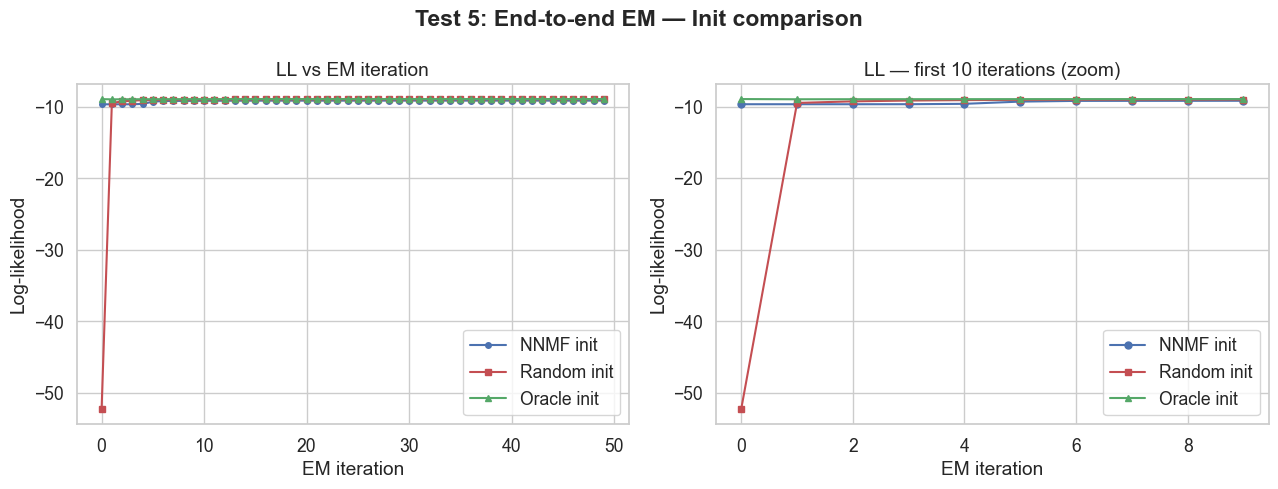


LL at iteration 0 — NNMF: -9.68  Random: -52.19  Oracle: -8.95


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Test 5: End-to-end EM — Init comparison", fontweight='bold')

iters = np.arange(len(lls_nnmf))
axes[0].plot(iters, lls_nnmf,   'b-o', ms=4, label='NNMF init')
axes[0].plot(iters, lls_random, 'r-s', ms=4, label='Random init')
axes[0].plot(iters, lls_oracle, 'g-^', ms=4, label='Oracle init')
axes[0].set_xlabel("EM iteration"); axes[0].set_ylabel("Log-likelihood")
axes[0].set_title("LL vs EM iteration")
axes[0].legend()

# Zoom: first 10 iterations to show LL at init
n_zoom = min(10, len(lls_nnmf))
axes[1].plot(iters[:n_zoom], lls_nnmf[:n_zoom],   'b-o', ms=5, label='NNMF init')
axes[1].plot(iters[:n_zoom], lls_random[:n_zoom], 'r-s', ms=5, label='Random init')
axes[1].plot(iters[:n_zoom], lls_oracle[:n_zoom], 'g-^', ms=5, label='Oracle init')
axes[1].set_xlabel("EM iteration"); axes[1].set_ylabel("Log-likelihood")
axes[1].set_title("LL — first 10 iterations (zoom)")
axes[1].legend()

plt.tight_layout()
plt.savefig("init_test5_em_comparison.pdf", bbox_inches='tight')
plt.show()

print(f"\nLL at iteration 0 — NNMF: {float(lls_nnmf[0]):.2f}  Random: {float(lls_random[0]):.2f}  Oracle: {float(lls_oracle[0]):.2f}")

---
## Test 6 — Data sensitivity: init quality vs T

How does initialization quality degrade when data is short?

Metrics per T: `‖J_hat − J_lin_true‖`, subspace angle of C, spectral radius of A_init.

In [25]:
T_sweep = [50, 100, 200, 500, 1000]
results_T = []  # list of dicts

for T_sw in T_sweep:
    key_sw = jr.PRNGKey(SEED + T_sw * 3)
    _, obs_sw,_, _ =generate_synthetic_data(
        num_samples=B,
        num_timesteps=T_sw,
        state_dim=D,
        emission_dim=N,
        cell_types=2,
        key=key_sw)
    if obs_sw.ndim == 2: obs_sw = obs_sw[None]
    Yc_sw, _ = flatten_and_center(obs_sw)

    # Stage 1: J quality
    Jh_sw = estimate_J(Yc_sw, dale_mask)
    Yp_sw, Yf_sw = Yc_sw[:, :-1], Yc_sw[:, 1:]
    j_fit_err = float(jnp.linalg.norm(Yf_sw - Jh_sw @ Yp_sw, 'fro') / jnp.linalg.norm(Yf_sw, 'fro'))
    j_sign_viol = int(jnp.sum(Jh_sw[:, :N_E] < -tol) + jnp.sum(Jh_sw[:, N_E:] > tol))

    # Full init
    try:
        ip_sw = model.initialize(obs_sw)
        C_sw = ip_sw.emissions.weights
        A_sw = ip_sw.dynamics.weights

        # Subspace angle
        Qc_sw, _ = jnp.linalg.qr(C_sw)
        Qc_tr, _ = jnp.linalg.qr(C_true)
        ang_sw = float(np.degrees(subspace_angles(np.array(Qc_sw), np.array(Qc_tr)).mean()))

        # Spectral radius
        sr_sw = float(jnp.max(jnp.abs(jnp.linalg.eigvals(A_sw))))

        # C nonneg violations
        c_neg = int(jnp.sum(C_sw < -1e-6))
    except Exception as e:
        print(f"  T={T_sw}: initialization failed — {e}")
        ang_sw, sr_sw, c_neg = float('nan'), float('nan'), -1

    results_T.append(dict(
        T=T_sw,
        j_fit_err=j_fit_err,
        j_sign_viol=j_sign_viol,
        subspace_angle=ang_sw,
        spectral_radius=sr_sw,
        c_neg_violations=c_neg,
    ))
    print(f"  T={T_sw:5d}  J_fit={j_fit_err:.3f}  J_viol={j_sign_viol:3d}  "
          f"subspace_angle={ang_sw:.1f}°  sr(A)={sr_sw:.3f}  C_neg={c_neg}")

Y shape (250, 20)
  T=   50  J_fit=0.960  J_viol=  0  subspace_angle=53.7°  sr(A)=0.574  C_neg=0
Y shape (500, 20)
  T=  100  J_fit=0.960  J_viol=  0  subspace_angle=50.0°  sr(A)=0.639  C_neg=0
Y shape (1000, 20)
  T=  200  J_fit=0.976  J_viol=  0  subspace_angle=50.1°  sr(A)=0.556  C_neg=0
Y shape (2500, 20)
  T=  500  J_fit=0.980  J_viol=  0  subspace_angle=46.2°  sr(A)=0.516  C_neg=0
Y shape (5000, 20)
  T= 1000  J_fit=0.980  J_viol=  0  subspace_angle=51.5°  sr(A)=0.545  C_neg=0


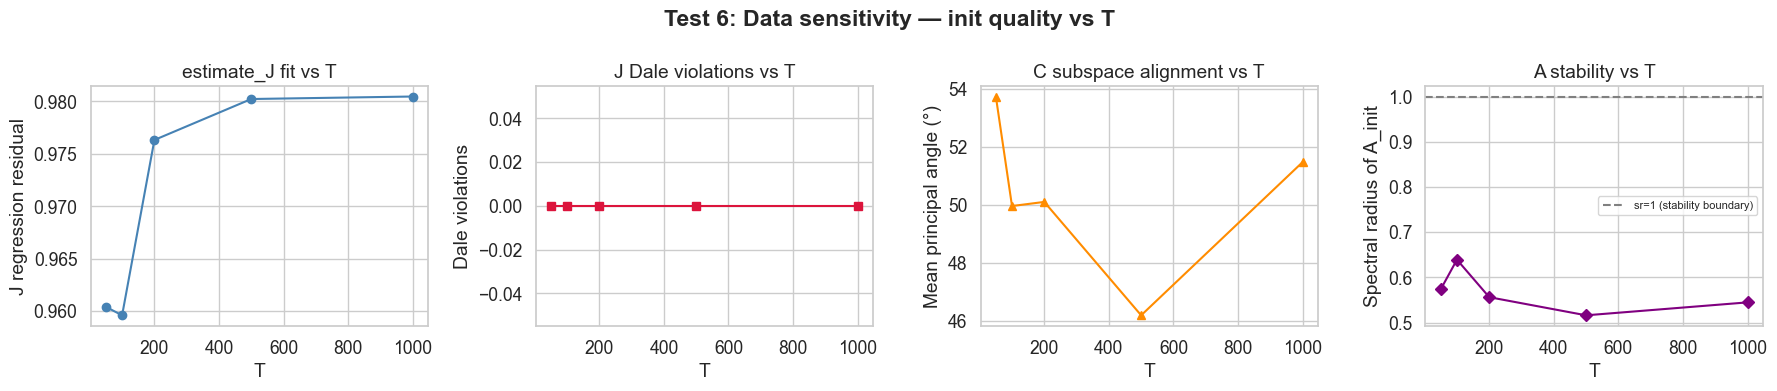

In [26]:
T_plot     = [r['T'] for r in results_T]
j_errs     = [r['j_fit_err'] for r in results_T]
j_viols    = [r['j_sign_viol'] for r in results_T]
sub_angles = [r['subspace_angle'] for r in results_T]
spec_rads  = [r['spectral_radius'] for r in results_T]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Test 6: Data sensitivity — init quality vs T", fontweight='bold')

axes[0].plot(T_plot, j_errs, 'o-', color='steelblue')
axes[0].set_xlabel("T"); axes[0].set_ylabel("J regression residual")
axes[0].set_title("estimate_J fit vs T")

axes[1].plot(T_plot, j_viols, 's-', color='crimson')
axes[1].set_xlabel("T"); axes[1].set_ylabel("Dale violations")
axes[1].set_title("J Dale violations vs T")

axes[2].plot(T_plot, sub_angles, '^-', color='darkorange')
axes[2].set_xlabel("T"); axes[2].set_ylabel("Mean principal angle (°)")
axes[2].set_title("C subspace alignment vs T")

axes[3].plot(T_plot, spec_rads, 'D-', color='purple')
axes[3].axhline(1.0, color='gray', ls='--', label='sr=1 (stability boundary)')
axes[3].set_xlabel("T"); axes[3].set_ylabel("Spectral radius of A_init")
axes[3].set_title("A stability vs T")
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig("init_test6_data_sensitivity.pdf", bbox_inches='tight')
plt.show()

---
## Test 7 — Constraint audit: Dale violations at every pipeline stage

For each stage, measure the maximum constraint violation. All bars should be at or near zero.

In [27]:
# ── Rerun pipeline step-by-step and record violations ────────────────────────
audit = {}

# Stage 1: J from estimate_J
J_audit = estimate_J(Y_center, dale_mask)
# E-columns: J[:, j] >= 0 for j in E-neurons
e_col_viol = float(jnp.max(jnp.maximum(0, -J_audit[:, :N_E])))  # max negative entry in E-cols
i_col_viol = float(jnp.max(jnp.maximum(0,  J_audit[:, N_E:])))  # max positive entry in I-cols
audit['J: E-col min<0'] = e_col_viol
audit['J: I-col max>0'] = i_col_viol

# Stage 2: NMF factors
bf_audit = blockwise_NMF(J_audit, constraints)
U_audit  = [t[0] for t in bf_audit]
V_audit  = [t[1] for t in bf_audit]
U_nonneg_viol = float(max(float(jnp.max(jnp.maximum(0, -u))) for u in U_audit))
V_nonneg_viol = float(max(float(jnp.max(jnp.maximum(0, -v))) for v in V_audit))
audit['U: min entry < 0'] = U_nonneg_viol
audit['V: min entry < 0'] = V_nonneg_viol

# Stage 3: C from initialize_emissions
C_audit  = init_params.emissions.weights   # (N, D)
c_nonneg = float(jnp.max(jnp.maximum(0, -C_audit)))
c_block  = max(float(jnp.max(jnp.abs(C_audit[:N_E, D_E:]))),   # E rows, I cols
               float(jnp.max(jnp.abs(C_audit[N_E:, :D_E]))))   # I rows, E cols
audit['C: nonneg violation'] = c_nonneg
audit['C: off-block leakage'] = c_block

# Stage 4: A from initialize_dynamics
A_audit = init_params.dynamics.weights   # (D, D)
a_dale_viol = 0.0
for j in range(D):
    col_j = A_audit[:, j]
    off   = jnp.concatenate([col_j[:j], col_j[j+1:]])
    if dynamics_mask[j] == 1:
        a_dale_viol = max(a_dale_viol, float(jnp.max(jnp.maximum(0, -off))))
    else:
        a_dale_viol = max(a_dale_viol, float(jnp.max(jnp.maximum(0,  off))))
audit['A: Dale violation'] = a_dale_viol

print("Stage-by-stage constraint audit:")
for k, v in audit.items():
    status = "✓" if v < 1e-4 else "✗ VIOLATION"
    print(f"  {k:30s}  max_viol = {v:.2e}  {status}")

Stage-by-stage constraint audit:
  J: E-col min<0                  max_viol = 0.00e+00  ✓
  J: I-col max>0                  max_viol = 0.00e+00  ✓
  U: min entry < 0                max_viol = 0.00e+00  ✓
  V: min entry < 0                max_viol = 0.00e+00  ✓
  C: nonneg violation             max_viol = 0.00e+00  ✓
  C: off-block leakage            max_viol = 0.00e+00  ✓
  A: Dale violation               max_viol = 0.00e+00  ✓


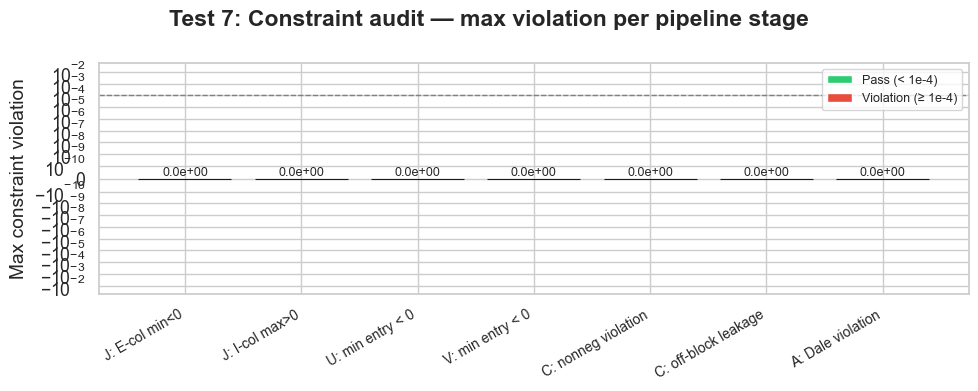

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Test 7: Constraint audit — max violation per pipeline stage", fontweight='bold')

labels = list(audit.keys())
values = [audit[k] for k in labels]
colors = ['#2ecc71' if v < 1e-4 else '#e74c3c' for v in values]

bars = ax.bar(range(len(labels)), values, color=colors, edgecolor='k', linewidth=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel("Max constraint violation")
ax.axhline(1e-4, color='gray', ls='--', lw=1, label='tol = 1e-4')
ax.set_yscale('symlog', linthresh=1e-10)
ax.legend(fontsize=9)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, max(val, 1e-12) * 2,
            f"{val:.1e}", ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Pass (< 1e-4)'),
                   Patch(facecolor='#e74c3c', label='Violation (≥ 1e-4)')]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig("init_test7_constraint_audit.pdf", bbox_inches='tight')
plt.show()

---
## Summary Dashboard

In [29]:
print("=" * 60)
print("CTDS INITIALIZATION TESTING — SUMMARY")
print("=" * 60)
print(f"Architecture:  N={N} (E={N_E}, I={N_I}),  D={D} (D_E={D_E}, D_I={D_I})")
print(f"Data:          T={T},  B={B}")
print()
print("Test 1 — estimate_J")
print(f"  Dale sign violations (T={T}): E={int(E_violations)}, I={int(I_violations)}")
print(f"  Regression residual:           {float(fit_err):.4f}")
print()
print("Test 2 — blockwise_NMF")
print(f"  Reconstruction err |J|:        {err_abs:.4f}")
print(f"  Reconstruction err J (signed): {err_signed:.4f}")
print(f"  min(U): {float(jnp.min(U_full)):.4f},  min(V): {float(jnp.min(V_stacked)):.4f}")
print()
print("Test 3 — initialize_emissions")
print(f"  min(C_init): {float(jnp.min(C_init)):.4f}  (>=0 required)")
print(f"  Off-block leakage: E→I={max_E_I_leak:.2e},  I→E={max_I_E_leak:.2e}")
print(f"  Mean subspace angle (C_init vs C_true): {angles_deg.mean():.2f}°")
print()
print("Test 4 — initialize_dynamics")
print(f"  Dale violations in A_init: {dale_viol}")
print(f"  Spectral radius: A_init={sr_init:.4f},  A_true={sr_true:.4f}")
print(f"  Relative error vs A_true:  init={err_init:.4f},  random={err_rand:.4f}")
print()
print("Test 5 — EM convergence")
print(f"  LL at iter 0:  NNMF={float(lls_nnmf[0]):.2f},  Random={float(lls_random[0]):.2f},  Oracle={float(lls_oracle[0]):.2f}")
print(f"  Final LL:      NNMF={float(lls_nnmf[-1]):.2f},  Random={float(lls_random[-1]):.2f},  Oracle={float(lls_oracle[-1]):.2f}")
print()
print("Test 7 — Constraint audit")
all_pass = all(v < 1e-4 for v in audit.values())
for k, v in audit.items():
    print(f"  {k}: {v:.2e} {'✓' if v < 1e-4 else '✗'}")
print(f"  Overall: {'ALL PASS ✓' if all_pass else 'VIOLATIONS FOUND ✗'}")

CTDS INITIALIZATION TESTING — SUMMARY
Architecture:  N=20 (E=14, I=6),  D=4 (D_E=2, D_I=2)
Data:          T=500,  B=5

Test 1 — estimate_J
  Dale sign violations (T=500): E=0, I=0
  Regression residual:           0.9814

Test 2 — blockwise_NMF
  Reconstruction err |J|:        0.3391
  Reconstruction err J (signed): 0.3391
  min(U): 0.0000,  min(V): 0.0000

Test 3 — initialize_emissions
  min(C_init): 0.0000  (>=0 required)
  Off-block leakage: E→I=0.00e+00,  I→E=0.00e+00
  Mean subspace angle (C_init vs C_true): 48.19°

Test 4 — initialize_dynamics
  Dale violations in A_init: 0
  Spectral radius: A_init=0.5113,  A_true=0.9500
  Relative error vs A_true:  init=0.7030,  random=1.1224

Test 5 — EM convergence
  LL at iter 0:  NNMF=-9.68,  Random=-52.19,  Oracle=-8.95
  Final LL:      NNMF=-9.16,  Random=-8.95,  Oracle=-8.94

Test 7 — Constraint audit
  J: E-col min<0: 0.00e+00 ✓
  J: I-col max>0: 0.00e+00 ✓
  U: min entry < 0: 0.00e+00 ✓
  V: min entry < 0: 0.00e+00 ✓
  C: nonneg violati